In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tkinter as tk
from tkinter import messagebox
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import pickle
import os

In [2]:
# Load and preprocess dataset
review_data = pd.read_csv(r"C:\Users\User\Downloads\archive (2)\IMDB Dataset.csv")  # Ensure this file is in your working directory


In [3]:
review_data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
review_data.dtypes

review       object
sentiment    object
dtype: object

In [5]:
review_data.shape

(50000, 2)

In [6]:
# Drop rows with missing 'review' or 'sentiment'
review_data.dropna(subset=["review", "sentiment"], inplace=True)

In [7]:
# Drop rows with NaNs left after mapping
review_data.dropna(subset=["sentiment"], inplace=True)

In [9]:
# Shuffle and limit size for performance
review_data = review_data.sample(frac=1).reset_index(drop=True).iloc[:5000]

In [10]:
review_data.columns

Index(['review', 'sentiment'], dtype='object')

In [11]:
review_data.describe()

,review,sentiment
count,5000,5000
unique,4993,2
top,Loved today's show!!! It was a variety and not...,positive
freq,2,2531


In [13]:
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
# Preprocess data
review_data['review'] = review_data['review'].astype(str)
review_data['sentiment'] = review_data['sentiment'].map({'positive': 1, 'negative': 0})


In [14]:
# Vectorize text data
cv = CountVectorizer(stop_words='english', max_features=10000)
X = cv.fit_transform(review_data['review'])
y = review_data['sentiment']


In [15]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.83


In [16]:
# Save model and vectorizer
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(cv, f)


In [17]:
# GUI code
def analyze_sentiment():
    review = text_input.get("1.0", "end-1c")
    if not review.strip():
        messagebox.showwarning("Warning", "Please enter a review")
        return

    try:
        with open("sentiment_model.pkl", "rb") as f:
            model = pickle.load(f)
        with open("vectorizer.pkl", "rb") as f:
            vectorizer = pickle.load(f)
    except FileNotFoundError:
        messagebox.showerror("Error", "Model or vectorizer file not found")
        return

    vect_text = vectorizer.transform([review])
    prediction = model.predict(vect_text)[0]
    
    if prediction == 1:
        result = "Positive 🙂"
    elif prediction == 0:
        result = "Negative 🙁"
    else:
        result = "Neutral 😐"

    output_label.config(text=f"Sentiment: {result}", fg="blue")

# Create GUI
app = tk.Tk()
app.title("Sentiment Analysis App")
app.geometry("500x300")

tk.Label(app, text="Enter your movie review:", font=("Helvetica", 12)).pack(pady=10)
text_input = tk.Text(app, height=5, width=60)
text_input.pack(pady=10)

tk.Button(app, text="Analyze", command=analyze_sentiment).pack(pady=10)
output_label = tk.Label(app, text="", font=("Helvetica", 14))
output_label.pack(pady=10)

app.mainloop()

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os

# Define emoji paths (or use fallback)
emoji_map = {
    'positive': 'emojis/positive.png',
    'negative': 'emojis/negative.png',
    'neutral': 'emojis/neutral.png'
}

# Fallback Unicode emojis
emoji_unicode = {
    'positive': '😊',
    'negative': '😞',
    'neutral': '😐'
}

def visualize_sentiment(predicted_sentiment, first_review=""):
    """
    Display sentiment using an emoji (image or Unicode fallback)
    and a review text below it.

    Parameters:
    - predicted_sentiment (str): 'positive', 'negative', or 'neutral'
    - first_review (str): Text of the review to show under the emoji
    """
    sentiment = predicted_sentiment.lower()

    # Try loading image-based emoji
    emoji_path = emoji_map.get(sentiment)
    emoji_img = None
    use_image = False

    if emoji_path and os.path.exists(emoji_path):
        try:
            emoji_img = mpimg.imread(emoji_path)
            use_image = True
        except Exception as e:
            print(f"Image load error: {e}")

    # Set up figure
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')  # Hide axes

    if use_image:
        # Display emoji image
        ax.imshow(emoji_img, extent=[0.2, 0.8, 0.4, 1])
    else:
        # Fallback: display Unicode emoji as large text
        ax.text(0.5, 0.7, emoji_unicode.get(sentiment, '❓'), fontsize=60,
                ha='center', va='center')

    # Display the review text below the emoji
    ax.text(0.5, 0.2, first_review, fontsize=12, ha='center', va='center',
            wrap=True, bbox=dict(facecolor='lightgray', alpha=0.5, boxstyle='round'))

    plt.tight_layout()
    plt.show()


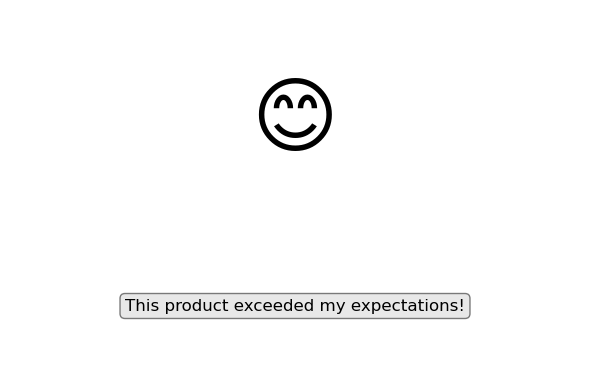

In [19]:
visualize_sentiment("positive", "This product exceeded my expectations!")